In [ ]:
!pip install xgboost

import pandas as pd
import numpy as np

from google.colab import files

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

import joblib

In [ ]:
# Upload your CSV file from your device
uploaded = files.upload()

# Automatically take the first uploaded file
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Dataset shape:", df.shape)
df.head()

Saving student_data.csv to student_data (1).csv
Dataset shape: (30, 13)


,gender,age,study_time,absences,famrel,freetime,health,activities,failures,G1,G2,G3,performance
0,F,17,2,4,4,3,3,yes,0,13,14,15,High
1,M,18,3,10,3,4,5,no,0,10,11,12,Medium
2,F,16,1,2,5,2,3,yes,0,15,15,16,High
3,M,16,2,6,4,3,4,yes,1,8,9,9,Low
4,F,17,3,0,5,4,3,yes,0,14,15,15,High


In [ ]:
df.info()
df.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   gender       30 non-null     object
 1   age          30 non-null     int64 
 2   study_time   30 non-null     int64 
 3   absences     30 non-null     int64 
 4   famrel       30 non-null     int64 
 5   freetime     30 non-null     int64 
 6   health       30 non-null     int64 
 7   activities   30 non-null     object
 8   failures     30 non-null     int64 
 9   G1           30 non-null     int64 
 10  G2           30 non-null     int64 
 11  G3           30 non-null     int64 
 12  performance  30 non-null     object
dtypes: int64(10), object(3)
memory usage: 3.2+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,30,2,F,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,30.0,NaN,NaN,NaN,16.866667,0.937102,15.0,16.0,17.0,18.0,18.0
study_time,30.0,NaN,NaN,NaN,2.033333,0.808717,1.0,1.0,2.0,3.0,3.0
absences,30.0,NaN,NaN,NaN,7.4,6.24555,0.0,2.0,6.0,11.5,20.0
famrel,30.0,NaN,NaN,NaN,3.7,1.118805,2.0,3.0,4.0,5.0,5.0
freetime,30.0,NaN,NaN,NaN,3.166667,0.874281,2.0,3.0,3.0,4.0,5.0
health,30.0,NaN,NaN,NaN,3.533333,0.973204,2.0,3.0,4.0,4.0,5.0
activities,30,2,yes,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
failures,30.0,NaN,NaN,NaN,0.8,0.996546,0.0,0.0,0.0,1.75,3.0
G1,30.0,NaN,NaN,NaN,10.833333,3.238596,5.0,8.0,11.0,14.0,15.0


In [ ]:
# 🔴 CHANGE THIS to your real target column name, e.g. "G3"
TARGET_COL = "G3"

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found! "
                     "Change TARGET_COL to your actual final grade column.")

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Remove rows with missing target (if any)
mask = ~y.isna()
X = X[mask]
y = y[mask]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (30, 12)
Target shape: (30,)


In [ ]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()

print("Numeric columns:", numeric_features)
print("Categorical columns:", categorical_features)

Numeric columns: ['age', 'study_time', 'absences', 'famrel', 'freetime', 'health', 'failures', 'G1', 'G2']
Categorical columns: ['gender', 'activities', 'performance']


In [ ]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (24, 12) (24,)
Test: (6, 12) (6,)


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, random_state=42
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    ),
    "SVR": SVR()
}

results = []
fitted_models = {}

for name, model in models.items():
    print(f"\n================ {name} ================")

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append((name, mae, rmse, r2))

    print(f"MAE  : {mae:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R²   : {r2:.3f}")


================ Linear Regression ================
MAE  : 0.744
RMSE : 0.885
R²   : 0.875

================ Random Forest ================
MAE  : 0.452
RMSE : 0.610
R²   : 0.941

================ XGBoost ================
MAE  : 0.555
RMSE : 0.717
R²   : 0.918

================ SVR ================
MAE  : 0.487
RMSE : 0.626
R²   : 0.937


In [ ]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2"]
)

results_df.sort_values(by="R2", ascending=False)

,Model,MAE,RMSE,R2
1,Random Forest,0.451667,0.609570,0.940548
3,SVR,0.486765,0.626273,0.937245
2,XGBoost,0.554792,0.716933,0.917761
0,Linear Regression,0.744389,0.884539,0.874814


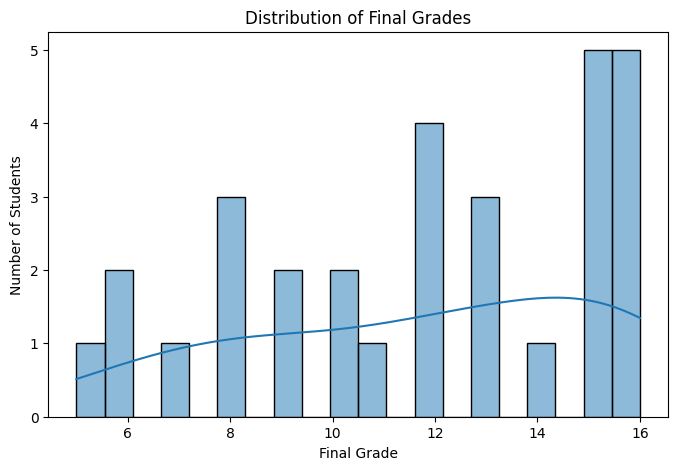

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(y, bins=20, kde=True)
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

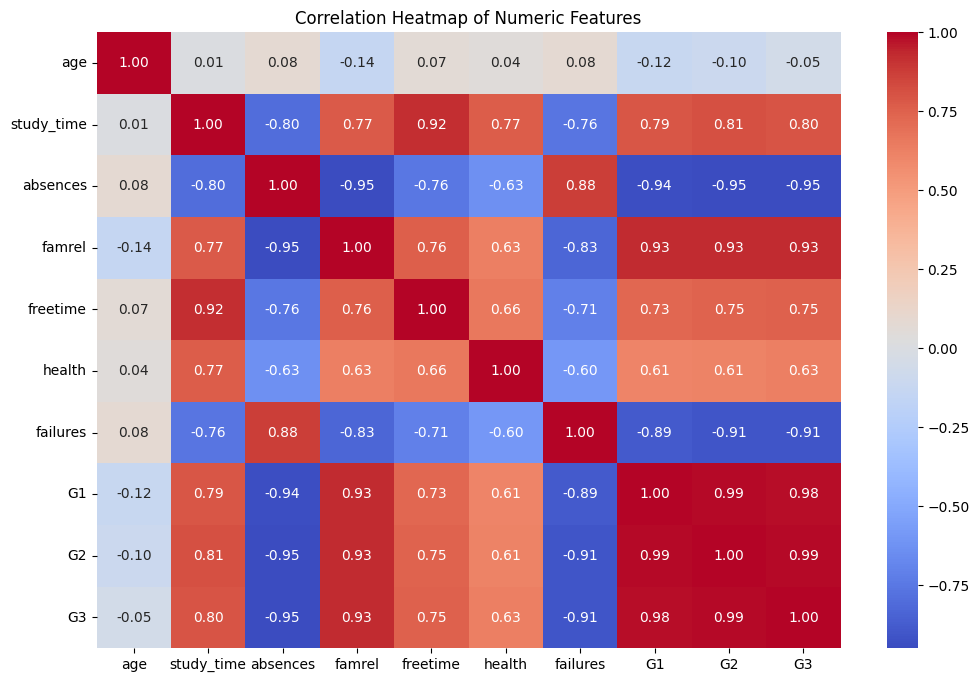

In [ ]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

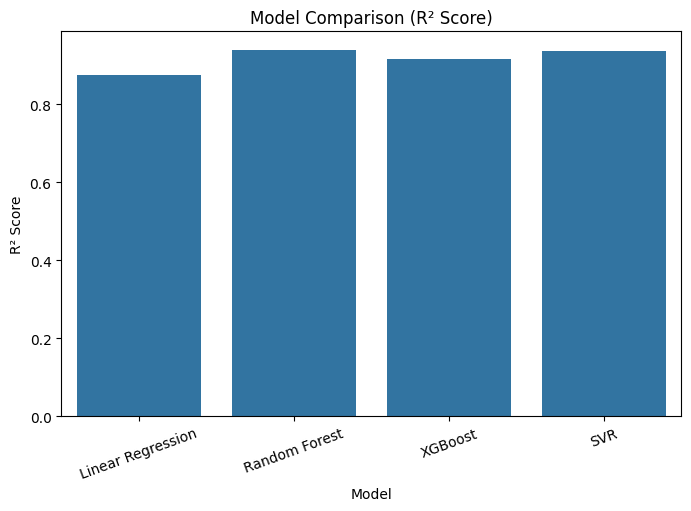

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=results_df, x="Model", y="R2")
plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()

Best model is: Random Forest


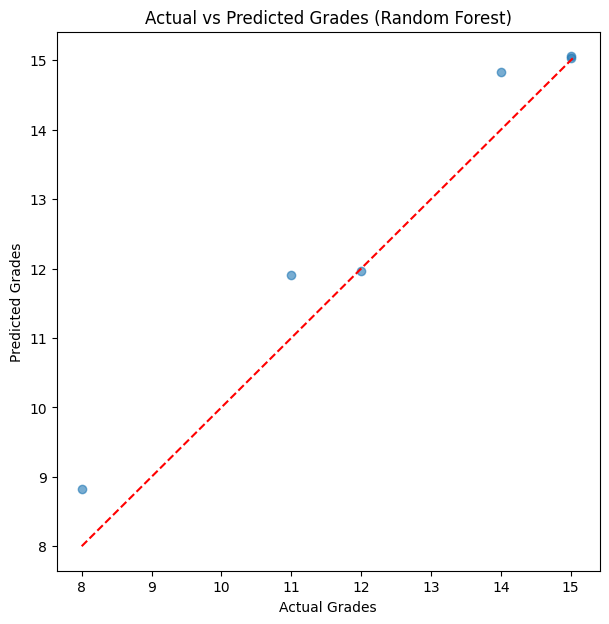

In [ ]:
# Pick model with highest R²
best_row = results_df.sort_values(by="R2", ascending=False).iloc[0]
best_name = best_row["Model"]
print("Best model is:", best_name)

best_pipeline = fitted_models[best_name]

y_pred_best = best_pipeline.predict(X_test)

plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_best, alpha=0.6)
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel("Actual Grades")
plt.ylabel("Predicted Grades")
plt.title(f"Actual vs Predicted Grades ({best_name})")
plt.show()

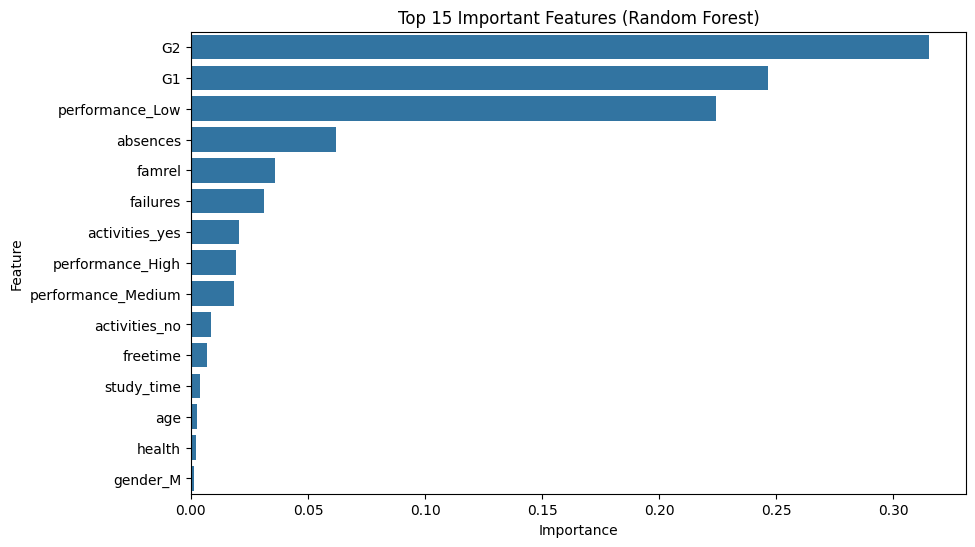

In [ ]:
if hasattr(best_pipeline.named_steps["model"], "feature_importances_"):
    # numeric feature names
    feature_names_num = numeric_features

    # categorical one-hot names
    ohe = best_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
    feature_names_cat = ohe.get_feature_names_out(categorical_features)

    feature_names = np.concatenate([feature_names_num, feature_names_cat])

    importances = best_pipeline.named_steps["model"].feature_importances_

    feat_imp_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False).head(15)

    plt.figure(figsize=(10,6))
    sns.barplot(data=feat_imp_df, x="Importance", y="Feature")
    plt.title(f"Top 15 Important Features ({best_name})")
    plt.show()
else:
    print("Selected best model does not support feature_importances_.")

In [ ]:
joblib.dump(best_pipeline, "student_grade_predictor.pkl")
print("Saved model as student_grade_predictor.pkl")

Saved model as student_grade_predictor.pkl
